# <Model> on <N>x CMP 170HX (SM80) — <topology>, <runtime>

| Metric | Value |
|---|---|
| Decode, c=1 | <value> tok/s |
| Best aggregate | <value> tok/s at c=<n> |
| Prefill | <value> tok/s at <n> prompt tokens |
| TTFT | <value> s |

![chart](../assets/charts/<experiment>.png)

```
<one-line pull command: hf download <model> ... or docker pull ...>
```

[<Release, evidence repo, or collection link>](<url>)

Fill every `<placeholder>` from a receipt under `results/<experiment>/`. Do
not invent a number. Delete this instruction line before publishing.


# TEMPLATE — experiment notebook

Copy this file to `notebooks/YYYY-MM-DD-<model>-<topology>-<runtime>.ipynb`
and fill in each section. See `notebooks/README.md` for the schema. Do not
invent a number that is not in a receipt under `results/<experiment>/`.

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True runs the same harness against a running OpenAI-compatible
# endpoint whose URL comes from an environment variable. Never hardcode an
# endpoint address in this notebook.
import os

EXPERIMENT = "YYYY-MM-DD-model-topology-runtime"  # matches this notebook's filename, no extension
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
ENDPOINT_ENV_VAR = "BENCH_ENDPOINT_URL"  # set this env var before running with LIVE = True

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")
if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"LIVE=True but {ENDPOINT_ENV_VAR} is not set")
    print(f"endpoint     : from ${ENDPOINT_ENV_VAR} (not printed)")
else:
    print("endpoint     : n/a (replaying committed receipts)")


experiment   : YYYY-MM-DD-model-topology-runtime
results_dir  : ../results/YYYY-MM-DD-model-topology-runtime
LIVE         : False
endpoint     : n/a (replaying committed receipts)


In [2]:
# --- Helper: receipt loader ---------------------------------------------
import json
import os


def load_receipt(name, results_dir=RESULTS_DIR):
    """Load one JSON receipt from results_dir. Raises if missing."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return json.load(f)


def load_text(name, results_dir=RESULTS_DIR):
    """Load one text/markdown receipt from results_dir."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read()


def load_csv_rows(name, results_dir=RESULTS_DIR):
    """Load a telemetry CSV as a list of raw lines (sanitized values kept as strings)."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read().splitlines()


In [3]:
# --- Helper: table renderer ----------------------------------------------
from IPython.display import display, Markdown


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table with the given headers.
    Every header should carry its unit, e.g. 'Decode (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


## 1. Identity and pins

State model name and revision, shard count, image digest, runtime source
commit and patches, torch/engine versions, topology, and hardware. Every
pin comes from a receipt; state "not captured in receipts" rather than
guessing.

In [4]:
# Fill in from results/<experiment>/summary.json or equivalent.
pins = {
    "model": "",
    "revision": "",
    "shards": "",
    "image_digest": "",
    "runtime_source_commit": "",
    "torch_version": "",
    "engine_version": "",
    "topology": "",
    "hardware": "",
}
render_table(["Pin", "Value"], list(pins.items()))


| Pin | Value |
|---|---|
| model |  |
| revision |  |
| shards |  |
| image_digest |  |
| runtime_source_commit |  |
| torch_version |  |
| engine_version |  |
| topology |  |
| hardware |  |

## 2. Preflight and safety

Confirm the run followed the safety limits in `AGENTS.md`: forced airflow,
an 80 C core / 85 C memory stop condition, and a stop on Xid, GPU
disappearance, or memory error. State what was checked and the result.

In [5]:
preflight = {
    "forced_airflow_confirmed": None,
    "core_temp_stop_c": 80,
    "memory_temp_stop_c": 85,
    "xid_ecc_events": "",
    "storage_free_ok": None,
}
render_table(["Check", "Value"], list(preflight.items()))


| Check | Value |
|---|---|
| forced_airflow_confirmed | None |
| core_temp_stop_c | 80 |
| memory_temp_stop_c | 85 |
| xid_ecc_events |  |
| storage_free_ok | None |

## 3. Load gate

The readiness and deterministic-output check that must pass before any
measurement counts.

In [6]:
# gate = load_receipt("gate.json")
# render_table(["Field", "Value"], [("verdict", gate.get("verdict")), ...])


## 4. Functional gates

Protocol-level checks: sampling settings, token accounting method, fixture
sizes, and any pass/fail gate other than the load gate.

In [7]:
# Describe sampling (temperature, ignore_eos), token accounting (final
# usage object vs. stream events), and fixture sizes here.


## 5. Measurements

Tables and charts. Every axis label and table column states its unit and
denominator (for example "tok/s" and "concurrency, requests").

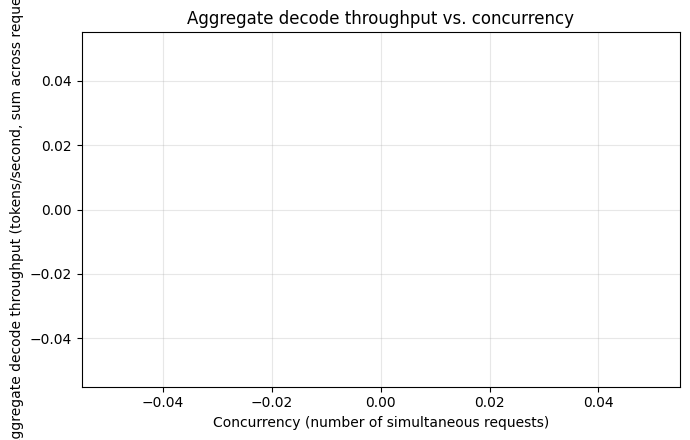

In [8]:
# --- Chart cell template ---------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))

x = []  # e.g. concurrency (number of concurrent requests)
y = []  # e.g. aggregate decode throughput (tok/s)

ax.plot(x, y, marker="o")
ax.set_xlabel("Concurrency (number of simultaneous requests)")
ax.set_ylabel("Aggregate decode throughput (tokens/second, sum across requests)")
ax.set_title("Aggregate decode throughput vs. concurrency")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Publication and limitations

State what the result does and does not show, known failures, and links to
the evidence source and any related comparison repository.

In [9]:
limitations = [
    "",
]
for item in limitations:
    print("-", item)


- 
